In [8]:
#!/usr/bin/env python3
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

# input directories
ARI_dir  = "/uufs/chpc.utah.edu/common/home/dycelab/users/jlu/collaborations/leaf_color/results/ARI_mARI_10-25-11-10-B5.tif"
NLCD_dir = "/uufs/chpc.utah.edu/common/home/dycelab/users/jlu/collaborations/leaf_color/results/nlcd_redlair.tif"

# NLCD classes
deciduous = 41
evergreen = 42

In [9]:
# -----------------------------
# Read ARI (10 m) bands
# -----------------------------
with rasterio.open(ARI_dir) as src:
    ari_profile = src.profile
    ari_crs = src.crs
    ari_transform = src.transform
    ari_shape = (src.height, src.width)

    # Bands:
    # 1 ARI, 2 mARI, 3 redness, 4 ARI peakdate, 5 mARI peakdate, 6 redness peakdate
    # redness = (Red - Green) / (Red + Green)
    b1 = src.read(1).astype(np.float32)
    b2 = src.read(2).astype(np.float32)
    b3 = src.read(3).astype(np.float32)
    d1 = src.read(4)  # keep dates as int
    d2 = src.read(5)
    d3 = src.read(6)

    ari_nodata = src.nodata

# Build a valid mask for indices
valid_idx = np.isfinite(b1) & np.isfinite(b2) & np.isfinite(b3)
if ari_nodata is not None:
    valid_idx &= (b1 != ari_nodata) & (b2 != ari_nodata) & (b3 != ari_nodata)

# -----------------------------
# Reproject NLCD (30 m) -> ARI grid (10 m), categorical nearest
# -----------------------------
nlcd_on_ari = np.full(ari_shape, fill_value=0, dtype=np.uint8)  # 0 as background/nodata

with rasterio.open(NLCD_dir) as nl:
    nl_arr = nl.read(1)
    nl_nodata = nl.nodata

    reproject(
        source=nl_arr,
        destination=nlcd_on_ari,
        src_transform=nl.transform,
        src_crs=nl.crs,
        dst_transform=ari_transform,
        dst_crs=ari_crs,
        resampling=Resampling.nearest,
        src_nodata=nl_nodata,
        dst_nodata=0
    )

# Keep only deciduous/evergreen
is_dec = (nlcd_on_ari == deciduous)
is_eve = (nlcd_on_ari == evergreen)

# Apply combined masks
dec_mask = valid_idx & is_dec
eve_mask = valid_idx & is_eve

print(f"Deciduous pixels: {dec_mask.sum():,}")
print(f"Evergreen pixels: {eve_mask.sum():,}")

Deciduous pixels: 36,119
Evergreen pixels: 6,634


In [10]:
# -----------------------------
# Pull samples into a DataFrame
# -----------------------------
def take(arr, mask):
    return arr[mask]

df = pd.DataFrame({
    "class": np.concatenate([np.full(dec_mask.sum(), "deciduous"),
                             np.full(eve_mask.sum(), "evergreen")]),
    "ARI":     np.concatenate([take(b1, dec_mask), take(b1, eve_mask)]),
    "mARI":    np.concatenate([take(b2, dec_mask), take(b2, eve_mask)]),
    "Redness": np.concatenate([take(b3, dec_mask), take(b3, eve_mask)]),
    "ARI_peak":     np.concatenate([take(d1, dec_mask), take(d1, eve_mask)]),
    "mARI_peak":    np.concatenate([take(d2, dec_mask), take(d2, eve_mask)]),
    "Redness_peak": np.concatenate([take(d3, dec_mask), take(d3, eve_mask)]),
})

In [11]:
df

,class,ARI,mARI,Redness,ARI_peak,mARI_peak,Redness_peak
0,deciduous,19.761053,5.153682,0.153846,298.0,298.0,313.0
1,deciduous,22.738346,5.646709,0.260718,301.0,298.0,313.0
2,deciduous,22.787596,5.390847,0.294382,311.0,301.0,313.0
3,deciduous,22.784767,5.222795,0.262222,311.0,301.0,313.0
4,deciduous,32.405239,6.779176,0.171548,303.0,303.0,313.0
...,...,...,...,...,...,...,...
42748,evergreen,28.539797,3.801501,0.194245,306.0,306.0,306.0
42749,evergreen,21.901709,3.948878,0.027375,306.0,306.0,313.0
42750,evergreen,21.901709,3.948878,0.027375,306.0,306.0,313.0
42751,evergreen,32.545143,5.597515,-0.032911,303.0,298.0,303.0


Text(0.5, 0.98, 'ARI / mARI / Redness by NLCD class (Deciduous vs Evergreen)')

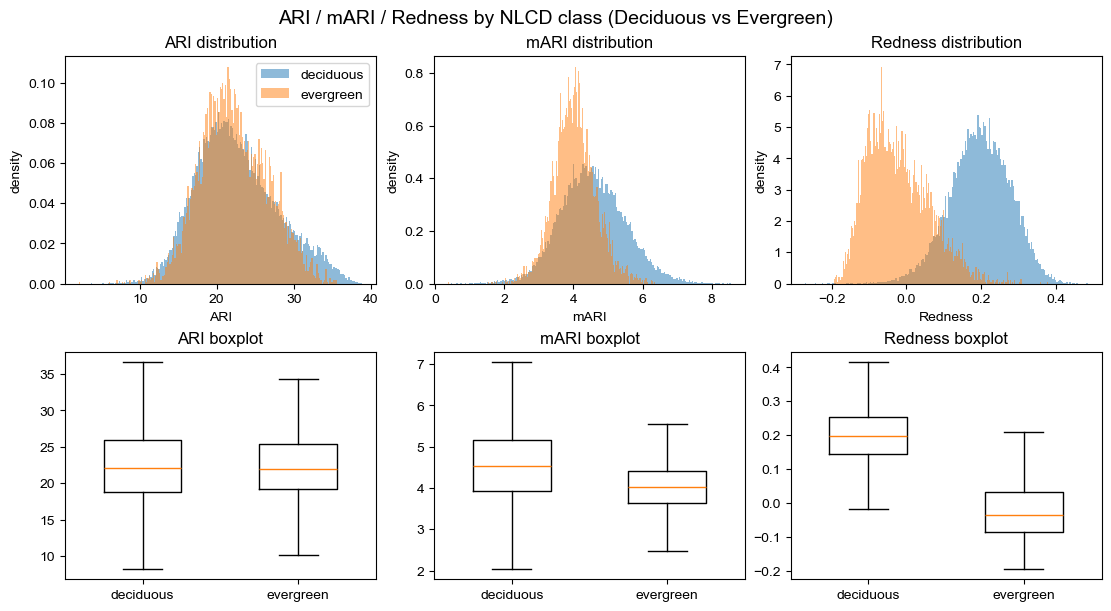

In [15]:
# -----------------------------
# Plots: histograms + boxplots
# -----------------------------
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.serif'] = ['Arial']

fig, axes = plt.subplots(2, 3, figsize=(11, 6), constrained_layout=True)

for j, col in enumerate(["ARI", "mARI", "Redness"]):
    ax = axes[0, j]
    ax.hist(dec[col].values, bins=200, alpha=0.5, density=True, label="deciduous")
    ax.hist(eve[col].values, bins=200, alpha=0.5, density=True, label="evergreen")
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("density")
    if j == 0:
        ax.legend()

    ax2 = axes[1, j]
    ax2.boxplot([dec[col].values, eve[col].values], labels=["deciduous", "evergreen"], showfliers=False,widths=0.5)
    ax2.set_title(f"{col} boxplot")

fig.suptitle("ARI / mARI / Redness by NLCD class (Deciduous vs Evergreen)", fontsize=14)

In [16]:
# -----------------------------
# Peak-date comparison
# -----------------------------
for col in ["ARI_peak", "mARI_peak", "Redness_peak"]:
    a = dec[col].values
    b = eve[col].values
    a = a[a != 0]
    b = b[b != 0]
    if len(a) > 0 and len(b) > 0:
        print(f"{col}: median dec={np.median(a):.1f}, median eve={np.median(b):.1f}, KS={ks_stat(a,b):.3f}")

############ redness may be still high at the "brown stage", therefore the peak date is late
############ should we try a later window?
############ or try different NDVI and NIR gates to make sure we are looking at green-red, not brown
############ or rely on the peak date identified by mARI, and use redness on that peak date as the anthocyanin level.

ARI_peak: median dec=306.0, median eve=306.0, KS=0.040
mARI_peak: median dec=303.0, median eve=306.0, KS=0.159
Redness_peak: median dec=313.0, median eve=308.0, KS=0.451


In [17]:
# -----------------------------
# Separation metrics: AUC, Cohen's d, KS
# -----------------------------
# AUC (Area Under the ROC Curve)
# AUC answers: If I randomly pick one deciduous pixel and one evergreen pixel, what is the probability that the deciduous pixel has a higher index value?
    # AUC = 0.5 → no separation
    # AUC = 1.0 → perfect separation
    # AUC = 0.0 → perfect separation but reversed direction

def auc_from_scores(pos_scores, neg_scores):
    # AUC = P(score_pos > score_neg) + 0.5*P(equal)
    x = np.asarray(pos_scores)
    y = np.asarray(neg_scores)
    # rank-based AUC via Mann–Whitney U
    scores = np.concatenate([x, y])
    labels = np.concatenate([np.ones_like(x, dtype=np.int8), np.zeros_like(y, dtype=np.int8)])

    order = np.argsort(scores, kind="mergesort")
    ranks = np.empty_like(order, dtype=np.float64)
    ranks[order] = np.arange(1, len(scores) + 1)

    # tie handling: average ranks for ties
    s_sorted = scores[order]
    r_sorted = ranks[order]
    i = 0
    while i < len(scores):
        j = i + 1
        while j < len(scores) and s_sorted[j] == s_sorted[i]:
            j += 1
        if j - i > 1:
            r_mean = r_sorted[i:j].mean()
            r_sorted[i:j] = r_mean
        i = j
    ranks[order] = r_sorted

    R_pos = ranks[labels == 1].sum()
    n_pos = (labels == 1).sum()
    n_neg = (labels == 0).sum()
    U = R_pos - n_pos * (n_pos + 1) / 2.0
    return U / (n_pos * n_neg)

# Cohen's d (Effect Size)
# Cohen's d measures: How far apart are the two group means, measured in standard deviations?
    # d = 1.0 → means differ by 1 full SD
    # d = 2.0 → extremely separated
    # d ≈ 0 → almost identical distributions

def cohens_d(a, b):
    a = np.asarray(a); b = np.asarray(b)
    ma, mb = a.mean(), b.mean()
    va, vb = a.var(ddof=1), b.var(ddof=1)
    na, nb = len(a), len(b)
    s = np.sqrt(((na - 1)*va + (nb - 1)*vb) / (na + nb - 2))
    return (ma - mb) / s if s > 0 else np.nan

# KS Statistic (Kolmogorov-Smirnov)
# KS measures: The maximum vertical distance between the two cumulative distribution functions (CDFs).
    # 0 → identical distributions
    # 1 → completely non-overlapping

def ks_stat(a, b):
    a = np.sort(np.asarray(a))
    b = np.sort(np.asarray(b))
    # empirical CDF max difference
    allv = np.sort(np.unique(np.concatenate([a, b])))
    ca = np.searchsorted(a, allv, side="right") / a.size
    cb = np.searchsorted(b, allv, side="right") / b.size
    return np.max(np.abs(ca - cb))

dec = df[df["class"] == "deciduous"]
eve = df[df["class"] == "evergreen"]

metrics = []
for col in ["ARI", "mARI", "Redness"]:
    # define "positive" as deciduous (arbitrary; AUC will flip if reversed)
    auc = auc_from_scores(dec[col].values, eve[col].values)
    d   = cohens_d(dec[col].values, eve[col].values)
    ks  = ks_stat(dec[col].values, eve[col].values)
    metrics.append([col, auc, d, ks, dec[col].median(), eve[col].median()])

met = pd.DataFrame(metrics, columns=["index", "AUC(dec>eve)", "Cohen_d(dec-eve)", "KS", "median_dec", "median_eve"])
met = met.sort_values("AUC(dec>eve)", ascending=False)
print("\nSeparation metrics (bigger AUC distance from 0.5 / bigger |d| / bigger KS => better separation):")
print(met.to_string(index=False))



Separation metrics (bigger AUC distance from 0.5 / bigger |d| / bigger KS => better separation):
  index  AUC(dec>eve)  Cohen_d(dec-eve)       KS  median_dec  median_eve
Redness      0.962684          2.701495 0.805241    0.198795   -0.034014
   mARI      0.680019          0.586318 0.307948    4.523850    4.014581
    ARI      0.508319          0.066038 0.062816   22.031866   21.896082
